## Inference and Interpretation

We have trained a VGG-Style model for chest - Xray classification problem. But Is the model just going to be saved???

Evaluating and Interpreting the model is a very crucial and Key component of a Deep Learning Project

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from model import VGG_XRay
from dataset_xray import get_xray_dataloaders

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
DATA_DIR = './data/chest_xray'

_, _, test_loader = get_xray_dataloaders(DATA_DIR, batch_size=32)

model = VGG_XRay(num_classes=2).to(device)
model_path = 'best_xray_vgg.pth'
model.load_state_dict(torch.load(model_path))

model.eval()
print("MOdel loaded successfully")
sns.set(style="whitegrid", font_scale=1.2)
class_names = ['NORMAL', 'PNEUMONIA']

Training samples: 4434
Validation samples: 782
Test samples: 624
MOdel loaded successfully


In [8]:
# Evaluation on the test set that the model never saw
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Ok 

In [9]:
print("Clasification report")
print(classification_report(all_labels, all_preds, target_names=class_names))

Clasification report
              precision    recall  f1-score   support

      NORMAL       0.99      0.46      0.63       234
   PNEUMONIA       0.75      1.00      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



The classification report indicates that the model performs well overall with an accuracy of **79%**, but it shows a clear bias toward predicting **PNEUMONIA**. The model achieves a **perfect recall (1.00)** for PNEUMONIA, meaning it correctly identifies all pneumonia cases, which is desirable in medical screening to avoid missing infections. However, its **recall for NORMAL cases is only 0.46**, suggesting that more than half of the normal chest X-rays are incorrectly classified as pneumonia. Despite this, the model’s **precision for NORMAL (0.99)** shows that when it does predict a case as normal, it is almost always correct. This imbalance implies the model prioritizes detecting pneumonia over correctly identifying normal cases—likely due to dataset imbalance or overfitting. Overall, while effective for screening, the model needs further tuning to reduce false pneumonia predictions and achieve better class balance.


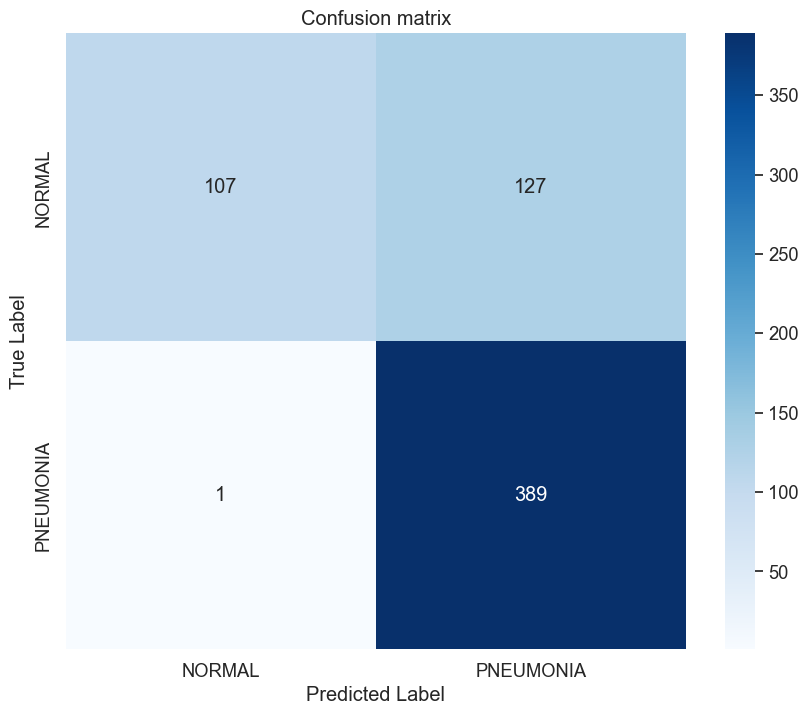

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Visual Model Failures

Found 23 misclassified examples in the first few batches.


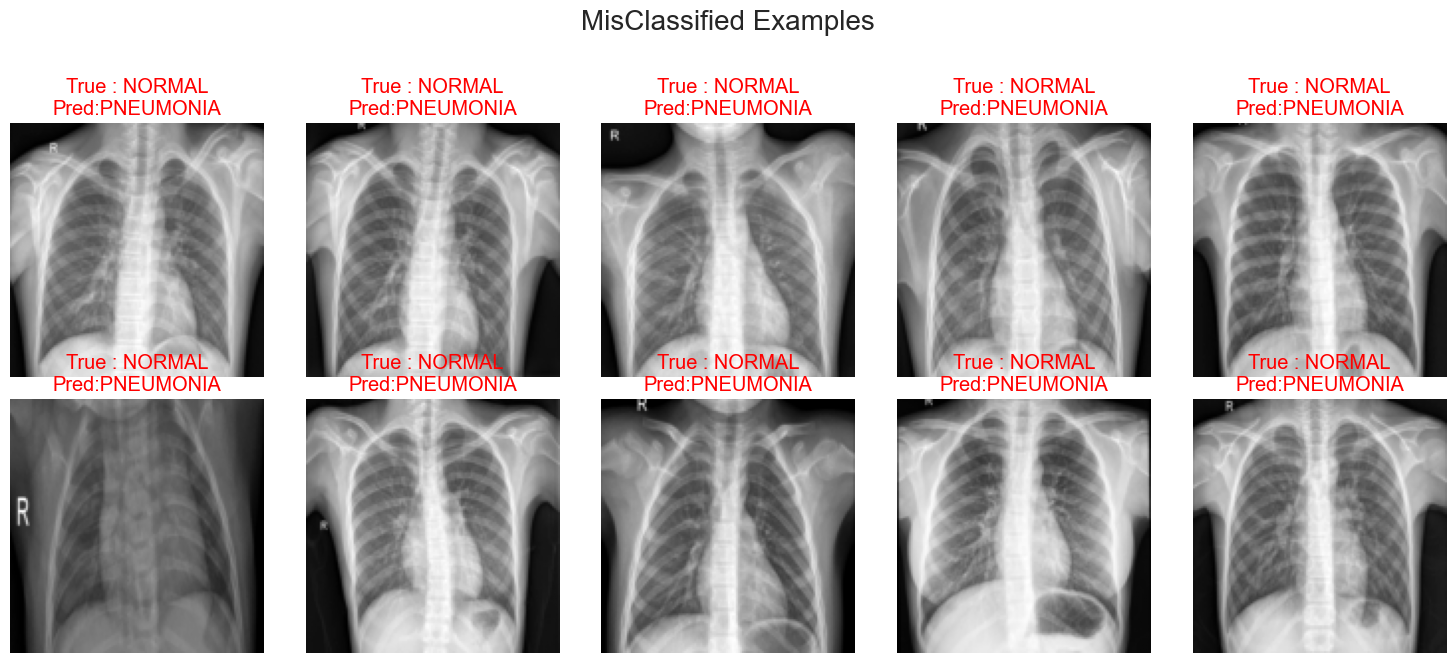

In [12]:
def misclassified(model, test_loader):
    misclassified_examples  = []
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev, labels_dev =  images.to(device), labels.to(device)
            outputs = model(images_dev)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                if preds[i] != labels_dev[i]:
                    misclassified_examples.append((images[i], labels[i], preds[i]))

                if len(misclassified_examples) > 20:
                    break
    
    print(f"Found {len(misclassified_examples)} misclassified examples in the first few batches.")
    

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle('MisClassified Examples', fontsize=20)
    for i, (img, true_label, pred_label) in enumerate(misclassified_examples[:10]):
        ax = axes[i // 5, i % 5]
        img = img.squeeze() # Remove channel dimension for grey scale
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True : {class_names[true_label]}\nPred:{class_names[pred_label]}", color='red')
        ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

misclassified(model, test_loader)

Found 38 rightly classified examples in the first few batches.


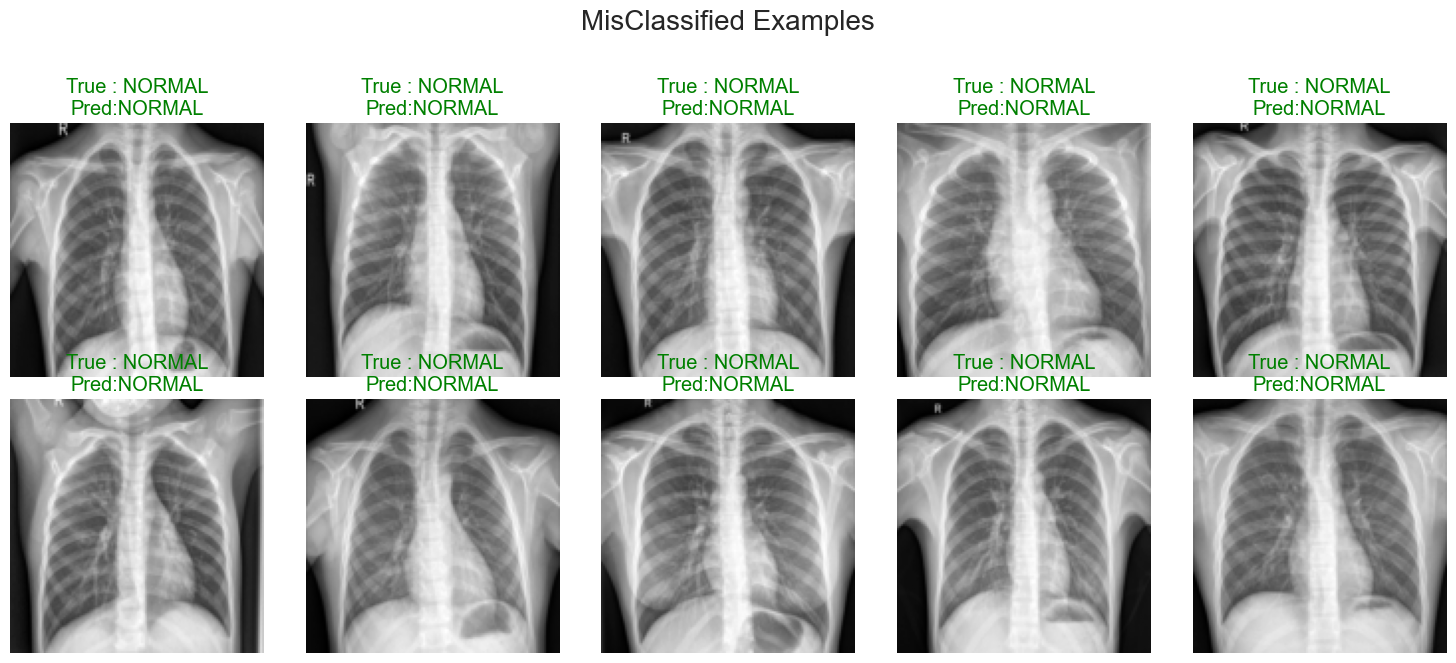

In [15]:
def classified(model, test_loader):
    classified_examples  = []
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev, labels_dev =  images.to(device), labels.to(device)
            outputs = model(images_dev)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                if preds[i] == labels_dev[i]:
                    classified_examples.append((images[i], labels[i], preds[i]))

                if len(classified_examples) > 20:
                    break
    
    print(f"Found {len(classified_examples)} rightly classified examples in the first few batches.")
    

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle('MisClassified Examples', fontsize=20)
    for i, (img, true_label, pred_label) in enumerate(classified_examples[:10]):
        ax = axes[i // 5, i % 5]
        img = img.squeeze() # Remove channel dimension for grey scale
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True : {class_names[true_label]}\nPred:{class_names[pred_label]}", color='green')
        ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

classified(model, test_loader)